In [1]:
# Load packages
from pathlib import Path
import os
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

In [2]:
import importlib

from skyline_qc.output_test import *
from skyline_qc import ImportFile
from skyline_qc.prm import *


# Skyline data path
skyline_path = "data/MARTHA/DE17501_Martha_results_dotp.csv"

# Import skyline data (includes column "Isotope Label Type" from Precursor)
skyline_importer = ImportFile(skyline_path)
skyline_DATA = skyline_importer.import_skyline_file()
skyline_data = skyline_DATA  # alias for downstream cells


The file data/MARTHA/DE17501_Martha_results_dotp.csv is valid.


In [3]:
# Isotope Label Type is added in ImportFile.import_skyline_file() (from Precursor).

# qREPs spike levels
qREPs_spike_levels = pd.read_csv('ratio/DE17501_ratio.csv')

# SDRF
sdrf_path = 'sdrf/sdrf_MARTHA_combined.sdrf.tsv'
sdrf_data = pd.read_csv(sdrf_path, sep='\t')



In [4]:
# Import and use function from output_test.py to get iRT peptides
iRT_peptides = get_irt_peptides(skyline_data)

print('This is the iRT peptides:')
print(iRT_peptides)

This is the iRT peptides:
['ELDKYGVSDYHK', 'YGVSDYHK', 'NLINNAK', 'TVEGVKDLQAQVVESAK', 'DLQAQVVESAK', 'ISEATDGLSDFLK', 'SQTPAEDTVK', 'SIELAEAK', 'ELDKYGVSDYYK', 'YGVSDYYK']


In [5]:
qc_samples = skyline_importer.suggest_qc_samples(skyline_DATA)

skyline_checker = CheckSkylineFile(skyline_path)
qc_data = skyline_checker.get_qc_data(qc_samples, skyline_DATA)
# Suggest qc samples
print('This is the qc samples:')
print(f'Number of qc samples: {len(qc_samples)}')
print(qc_samples)

This is the qc samples:
Number of qc samples: 23
['PRM_20251128_MarthaReselection_QC', 'PRM_20251128_MarthaReselection_QC_20251128151944', 'PRM_20251128_MarthaReselection_QC_20251201162324', 'PRM_20251128_MarthaReselection_QC_20251202120251', 'PRM_20251128_MarthaReselection_QC_20251208153500', 'PRM_20251128_MarthaReselection_QC_20251208161323', 'PRM_20251128_MarthaReselection_QC_20251209084653', 'PRM_20251128_MarthaReselection_QC_20251209092514', 'PRM_20251128_MarthaReselection_QC_20251209121038', 'PRM_20251128_MarthaReselection_QC_20251209124901', 'PRM_20251128_MarthaReselection_QC_20251209132508', 'PRM_20251128_MarthaReselection_QC_20251209140116', 'PRM_20251128_MarthaReselection_QC_20251209151815', 'PRM_20251128_MarthaReselection_QC_20251209155637', 'PRM_20251128_MarthaReselection_QC_20251210122424', 'PRM_20251128_MarthaReselection_QC_20251211110209', 'PRM_20251128_MarthaReselection_QC_20251213051215', 'PRM_20251128_MarthaReselection_QC_20251215153457', 'PRM_20251128_MarthaReselecti

In [6]:
# Get test samples (exclude QC samples from all replicate names)
skyline_checker = CheckSkylineFile(skyline_path)
test_samples = skyline_checker.get_test_samples(qc_samples, skyline_DATA)
test_data = skyline_checker.get_test_data(test_samples, skyline_DATA)
print('This is the test samples:')
print(f'Number of test samples: {len(test_samples)}')

This is the test samples:
Number of test samples: 861


In [7]:


# Show all Replicate in df here
qc_replicates = qc_samples
print(qc_replicates)
print(f'Number of QC replicates: {len(qc_replicates)}')


# Remove all rows in skyline_data that contains any of the qc_replicates
skyline_data = test_data
print(test_data.shape)

['PRM_20251128_MarthaReselection_QC', 'PRM_20251128_MarthaReselection_QC_20251128151944', 'PRM_20251128_MarthaReselection_QC_20251201162324', 'PRM_20251128_MarthaReselection_QC_20251202120251', 'PRM_20251128_MarthaReselection_QC_20251208153500', 'PRM_20251128_MarthaReselection_QC_20251208161323', 'PRM_20251128_MarthaReselection_QC_20251209084653', 'PRM_20251128_MarthaReselection_QC_20251209092514', 'PRM_20251128_MarthaReselection_QC_20251209121038', 'PRM_20251128_MarthaReselection_QC_20251209124901', 'PRM_20251128_MarthaReselection_QC_20251209132508', 'PRM_20251128_MarthaReselection_QC_20251209140116', 'PRM_20251128_MarthaReselection_QC_20251209151815', 'PRM_20251128_MarthaReselection_QC_20251209155637', 'PRM_20251128_MarthaReselection_QC_20251210122424', 'PRM_20251128_MarthaReselection_QC_20251211110209', 'PRM_20251128_MarthaReselection_QC_20251213051215', 'PRM_20251128_MarthaReselection_QC_20251215153457', 'PRM_20251128_MarthaReselection_QC_20251216162110', 'PRM_20251128_MarthaResele

In [8]:
test_data

,Precursor,Replicate,File Name,Peptide Retention Time,Retention Time Calculator Score,Predicted Retention Time,Peptide Sequence,Peptide,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,Protein Name,Isotope Label Type
475615,805.0424+++,PRM_20251128_MarthaReselection_Plate_1_A1,PRM_20251128_MarthaReselection_Plate_1_A1.raw,16.59,40.41,16.88,AAPAPQEATATFNSTADREDGHR,AAPAPQEATATFNSTADREDGHR,1.3533E+4,0.0083,0.6780,0.7215,QR5000058_ICAM2|P13598,light
476499,811.7146+++ (heavy),PRM_20251128_MarthaReselection_Plate_1_A1,PRM_20251128_MarthaReselection_Plate_1_A1.raw,16.59,40.41,16.88,AAPAPQEATATFNSTADREDGHR,AAPAPQEATATFNSTADREDGHR,1.3533E+4,0.0083,NaN,0.7779,QR5000058_ICAM2|P13598,heavy
28311,736.3757++,PRM_20251128_MarthaReselection_Plate_1_A1,PRM_20251128_MarthaReselection_Plate_1_A1.raw,14.64,22.09,14.83,AAVYHHFISDGVR,AAVYHHFISDGVR,1.4852E+6,0.6702,0.9521,0.8237,QR0280090_C3|P01024,light
29195,741.3798++ (heavy),PRM_20251128_MarthaReselection_Plate_1_A1,PRM_20251128_MarthaReselection_Plate_1_A1.raw,14.64,22.09,14.83,AAVYHHFISDGVR,AAVYHHFISDGVR,1.4852E+6,0.6702,NaN,0.8281,QR0280090_C3|P01024,heavy
30079,533.9512+++,PRM_20251128_MarthaReselection_Plate_1_A1,PRM_20251128_MarthaReselection_Plate_1_A1.raw,13.15,11.12,13.60,AAVYHHFISDGVRK,AAVYHHFISDGVRK,3.3933E+6,0.6296,0.9325,0.7579,QR0280090_C3|P01024,light
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583416,383.7097++ (heavy),PRM_20251218_MarthaReselection_Plate_9_H9,PRM_20251218_MarthaReselection_Plate_9_H9.raw,18.47,49.27,17.88,YSFLAR,YSFLAR,1.0996E+5,2.3907,NaN,0.8700,QR0520106_CSF1R|P07333,heavy
168820,854.4133++,PRM_20251218_MarthaReselection_Plate_9_H9,PRM_20251218_MarthaReselection_Plate_9_H9.raw,22.01,79.85,21.31,YVMLPVADQDQCIR,YVMLPVADQDQCIR,4.6978E+7,1.5614,0.9904,0.7511,QR5000013_HP|P00738,light
169704,859.4174++ (heavy),PRM_20251218_MarthaReselection_Plate_9_H9,PRM_20251218_MarthaReselection_Plate_9_H9.raw,22.01,79.85,21.31,YVMLPVADQDQCIR,YVMLPVADQDQCIR,4.6978E+7,1.5614,NaN,0.7468,QR5000013_HP|P00738,heavy
142300,748.3430++,PRM_20251218_MarthaReselection_Plate_9_H9,PRM_20251218_MarthaReselection_Plate_9_H9.raw,22.13,80.99,21.44,YYCFQGNQFLR,YYCFQGNQFLR,3.7834E+7,4.7141,0.9529,0.9007,QR4200150_HPX|P02790,light


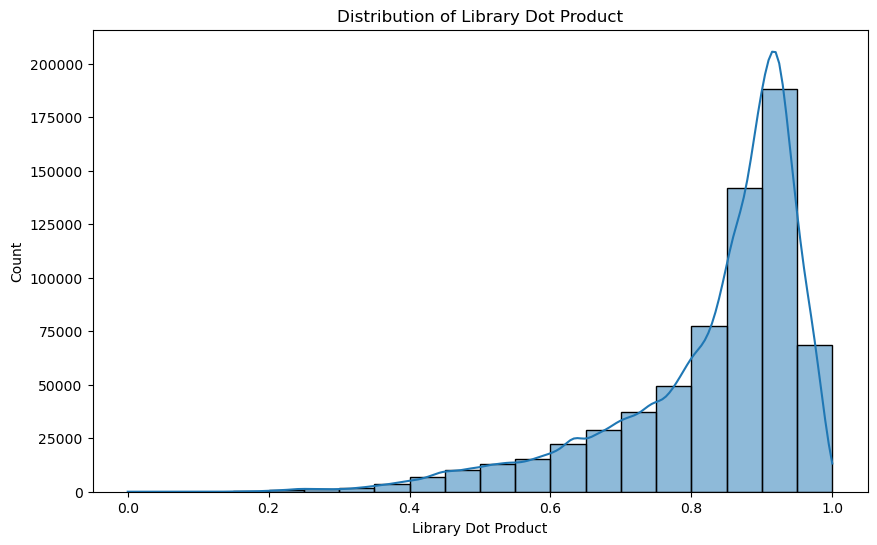

In [9]:
plot_library_dot_product_distribution(skyline_data)

In [10]:
skyline_clean = filter_library_dot_product(skyline_data, threshold=0.6)


In [11]:
# Summarise each peptide to count how many heavy or light signals are present in skyline_pivot
peptide_counts = summarise_peptide_counts(skyline_clean)


In [12]:
peptide_counts.head()

,Protein Name,Peptide,heavy_count,light_count
0,QR0140424_CKB|P12277,FCTGLTQIETLFK,861,215
1,QR0140424_CKB|P12277,FSEVLKR,861,12
2,QR0140424_CKB|P12277,GTGGVDTAAVGGVFDVSNADR,861,730
3,QR0140424_CKB|P12277,LEQGQAIDDLMPAQK,861,505
4,QR0140424_CKB|P12277,LLIEMEQR,836,97


In [13]:
report_summary = report_peptide_protein_summary(peptide_counts)

Number of unique peptides: 382
Number of unique proteins: 176


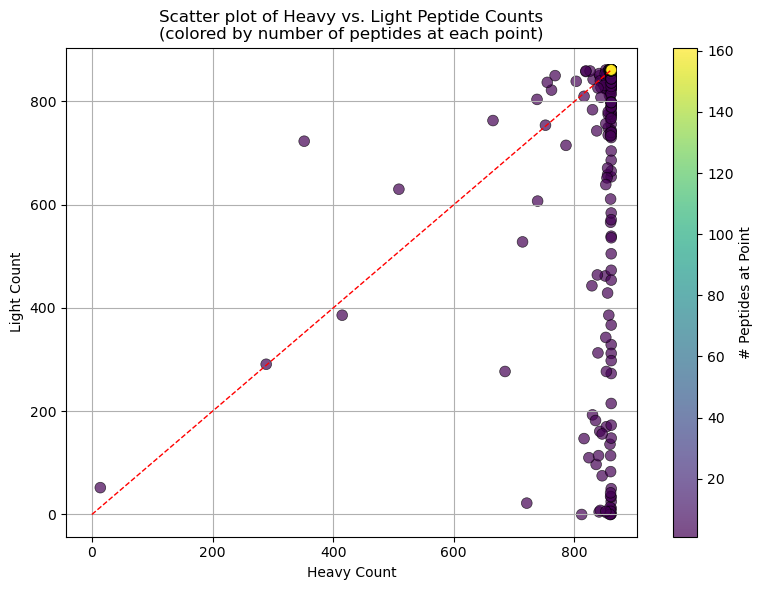

In [14]:
plot_heavy_light_scatter(peptide_counts)

In [15]:
# def suggest_most_abundant_peptides(peptide_counts, min_count=700):


In [16]:
filtered_peptide_counts = filter_peptide_counts(peptide_counts, light_cutoff=700, heavy_cutoff=700)

filtered_peptide_counts.head()


,Protein Name,Peptide,heavy_count,light_count
0,QR0140424_CKB|P12277,GTGGVDTAAVGGVFDVSNADR,861,730
1,QR0140840_SERPINA6|P08185,ITQDAQLK,861,861
2,QR0140840_SERPINA6|P08185,MNTVIAALSR,861,861
3,QR0140840_SERPINA6|P08185,WSAGLTSSQVDLYIPK,861,861
4,QR0221144_ADA2|Q9NZK5,DIPIEVCPISNQVLK,861,847


In [17]:
filtered_report_summary = report_peptide_protein_summary( filtered_peptide_counts)

Number of unique peptides: 309
Number of unique proteins: 148


In [ ]:
selected_peptides = filtered_peptide_counts['Peptide'].drop_duplicates().tolist()
# print length of selected_peptides
print(len(selected_peptides))

['GTGGVDTAAVGGVFDVSNADR',
 'ITQDAQLK',
 'MNTVIAALSR',
 'WSAGLTSSQVDLYIPK',
 'DIPIEVCPISNQVLK',
 'HGATVLTALGGILK',
 'HGATVLTALGGILKK',
 'KGHHEAEIKPLAQSHATK',
 'VDAFCGGSIVNEK',
 'ALDLSLK',
 'DYIFGNYIER',
 'ALVQQMEQLR',
 'DKVNSFFSTFK',
 'ISASAEELR',
 'LAPLAEDVR',
 'SLAELGGHLDQQVEEFRR',
 'VNSFFSTFK',
 'VGPLLACIIGTQFR',
 'TNQVNSGGVLLR',
 'LLEVPEGR',
 'TNFDNDIALVR',
 'AAVYHHFISDGVR',
 'AAVYHHFISDGVRK',
 'ILLQGTPVAQMTEDAVDAER',
 'RHQQTVTIPPK',
 'SSLSVPYVIVPLK',
 'TGLQEVEVK',
 'VELLHNPAFCSLATTK',
 'VRVELLHNPAFCSLATTK',
 'VVPEGIR',
 'LMQCLPNPEDVK',
 'LSCSYSHWSAPAPQCK',
 'LSLEIEQLELQR',
 'VKLVFQQFDLEPSEGCFYDYVK',
 'GSQWSDIEEFCNR',
 'LTCLQNLK',
 'QPYITQNYFPVGTVVEYECRPGYR',
 'NGLQSCPIKEDSFLQR',
 'TPLLSSLSATSNNSTVACIDR',
 'AVTSANIQEFAGCK',
 'AVTSANIQEFAGCKK',
 'IEDLPTMVTLGNSFLHK',
 'ILAGPAGDSNVVK',
 'TFVLNFIK',
 'VTLNGVPAQPLGPR',
 'VLDLSCNR',
 'GVNVCQETCTK',
 'VLTPDAFVCR',
 'DLLLPQPDLR',
 'VAAGAFQGLR',
 'YLFLNGNK',
 'FSAEFDFR',
 'ITTGGDVINNGLWNMVSVEELEHSISIK',
 'FTDLIQSGSFQLHLDSK',
 'EFNPLVIVGLSK',

In [19]:
# Pick theese columns from skyline_data
select_col = ['Replicate', 'Peptide Sequence', 'Protein Name', 'RatioLightToHeavy']

# Filtered skyline_data with selected_peptides
skyline_data_filtered = skyline_data[skyline_data['Peptide'].isin(selected_peptides)]

# Se;ect Replciate, Peptide Sequence, Protein Name and RatioLighToHeavy from skyline_data_filtered
skyline_data_filtered = skyline_data_filtered[select_col].drop_duplicates()


# # Merge skyline_data_filtered with sdrf_data using 'Replicate' from skyline and 'comment[data file]' from sdrf_data
skyline_merge = pd.merge(skyline_data_filtered, sdrf_data[['source name', 'characteristics[Sample]']], left_on='Replicate', right_on='source name', how='left')

# # Create column characteristics[Plate] from characteristics[Sample] (should be whatever comes after 'Plate_' in Replicate)
skyline_merge['characteristics[Plate]'] = skyline_merge['Replicate'].str.extract(r'Plate_(\d+)')


In [20]:
# Batch/Plate adjustment, correcting for each peptide within each plate (batch) 

pool_data = skyline_merge[skyline_merge['characteristics[Sample]'] == 'Pool']
# First, sort dataframe by Plate
pool_data = pool_data.sort_values('characteristics[Plate]')

pool_data.head()

,Replicate,Peptide Sequence,Protein Name,RatioLightToHeavy,source name,characteristics[Sample],characteristics[Plate]
4944,PRM_20251128_MarthaReselection_Plate_1_B2,AAVYHHFISDGVR,QR0280090_C3|P01024,1.1576,PRM_20251128_MarthaReselection_Plate_1_B2,Pool,1
23283,PRM_20251128_MarthaReselection_Plate_1_G12,IELYR,QR5000318_IGFBP1|P08833,0.0092,PRM_20251128_MarthaReselection_Plate_1_G12,Pool,1
23282,PRM_20251128_MarthaReselection_Plate_1_G12,IEDLPTMVTLGNSFLHK,QR0330186_VWF|P04275,0.0566,PRM_20251128_MarthaReselection_Plate_1_G12,Pool,1
23281,PRM_20251128_MarthaReselection_Plate_1_G12,IASFSQNCDIYPGKDFVQPPTK,QR0350145_KNG1|P01042,1.5691,PRM_20251128_MarthaReselection_Plate_1_G12,Pool,1
23280,PRM_20251128_MarthaReselection_Plate_1_G12,IASFSQNCDIYPGK,QR0350145_KNG1|P01042,1.9963,PRM_20251128_MarthaReselection_Plate_1_G12,Pool,1


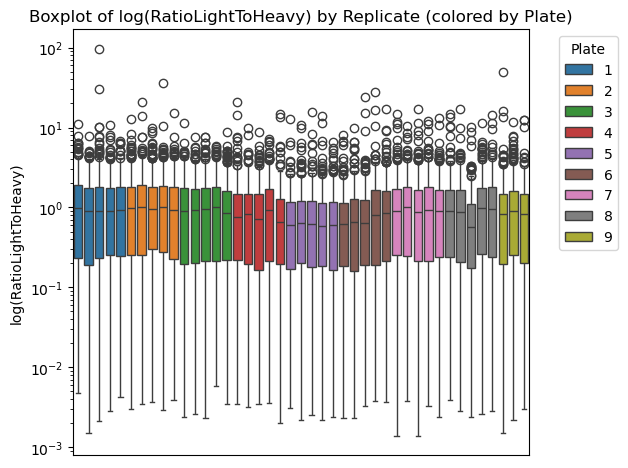

In [21]:
# Plot log_ratio of each sample in boxplot, colored by plate, but x-axis is Replicate, sorted by plate (though x labels are hidden).
plot_pool_boxplot(pool_data)


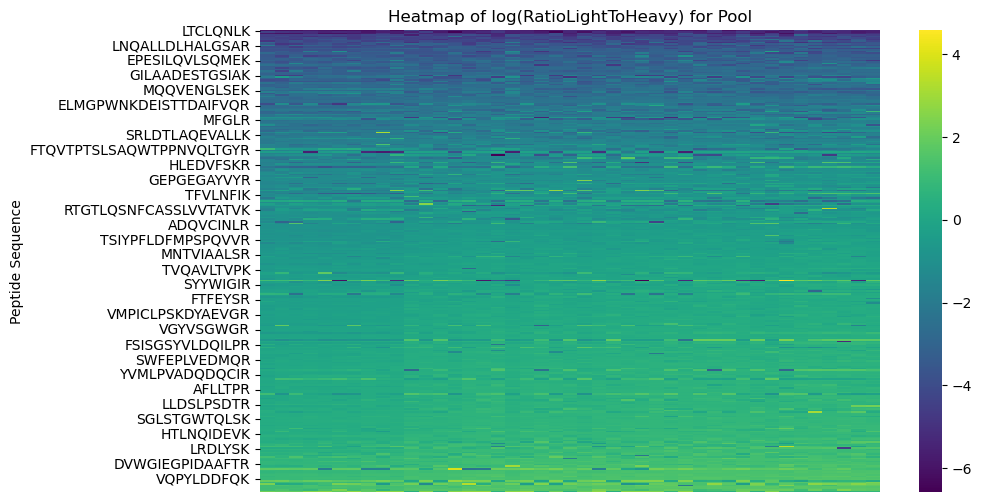

In [22]:
plot_pool_heatmap(pool_data)

In [23]:
pool_data.head()

,Replicate,Peptide Sequence,Protein Name,RatioLightToHeavy,source name,characteristics[Sample],characteristics[Plate]
4944,PRM_20251128_MarthaReselection_Plate_1_B2,AAVYHHFISDGVR,QR0280090_C3|P01024,1.1576,PRM_20251128_MarthaReselection_Plate_1_B2,Pool,1
23283,PRM_20251128_MarthaReselection_Plate_1_G12,IELYR,QR5000318_IGFBP1|P08833,0.0092,PRM_20251128_MarthaReselection_Plate_1_G12,Pool,1
23282,PRM_20251128_MarthaReselection_Plate_1_G12,IEDLPTMVTLGNSFLHK,QR0330186_VWF|P04275,0.0566,PRM_20251128_MarthaReselection_Plate_1_G12,Pool,1
23281,PRM_20251128_MarthaReselection_Plate_1_G12,IASFSQNCDIYPGKDFVQPPTK,QR0350145_KNG1|P01042,1.5691,PRM_20251128_MarthaReselection_Plate_1_G12,Pool,1
23280,PRM_20251128_MarthaReselection_Plate_1_G12,IASFSQNCDIYPGK,QR0350145_KNG1|P01042,1.9963,PRM_20251128_MarthaReselection_Plate_1_G12,Pool,1


,characteristics[Plate],Peptide Sequence,mean,std,intra_plate_cv
0,1,AAVYHHFISDGVR,0.88408,0.492877,0.557502
1,1,AAVYHHFISDGVRK,1.09988,0.146371,0.133079
2,1,ACIPTGPYPCGK,0.96442,0.057612,0.059738
3,1,ADQVCINLR,0.63904,0.033475,0.052382
4,1,AEATTLHVAPQGTAMAVSTFR,1.90414,0.255476,0.134169


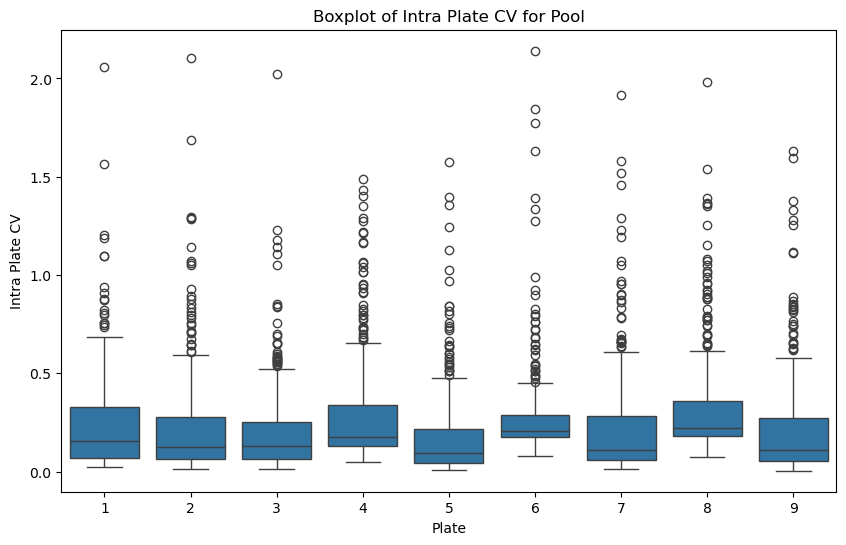

In [24]:
# Example usage:
peptide_plate_stats = calculate_intra_plate_cv(pool_data, col_name='characteristics[Plate]')
plot_intra_plate_cv_stats(peptide_plate_stats, col_name='characteristics[Plate]')


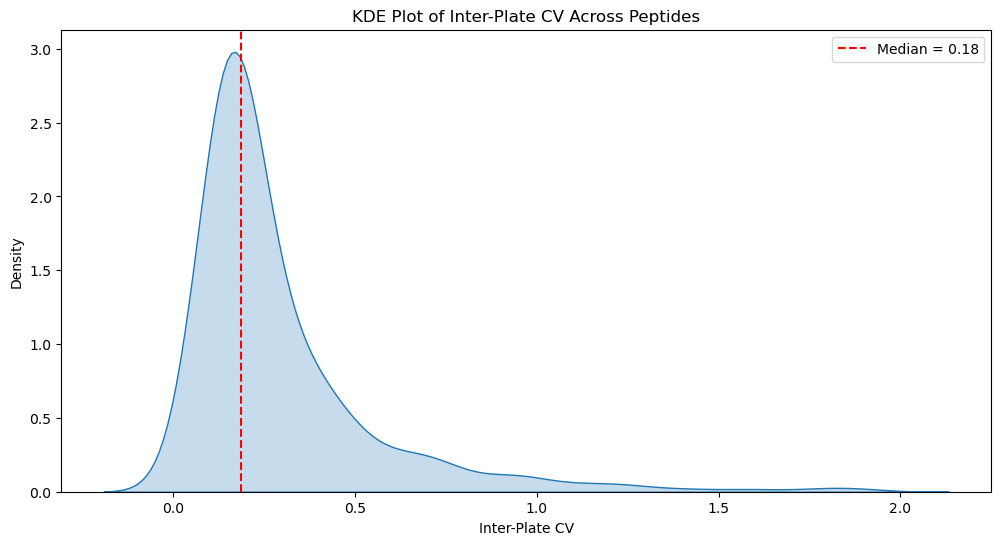

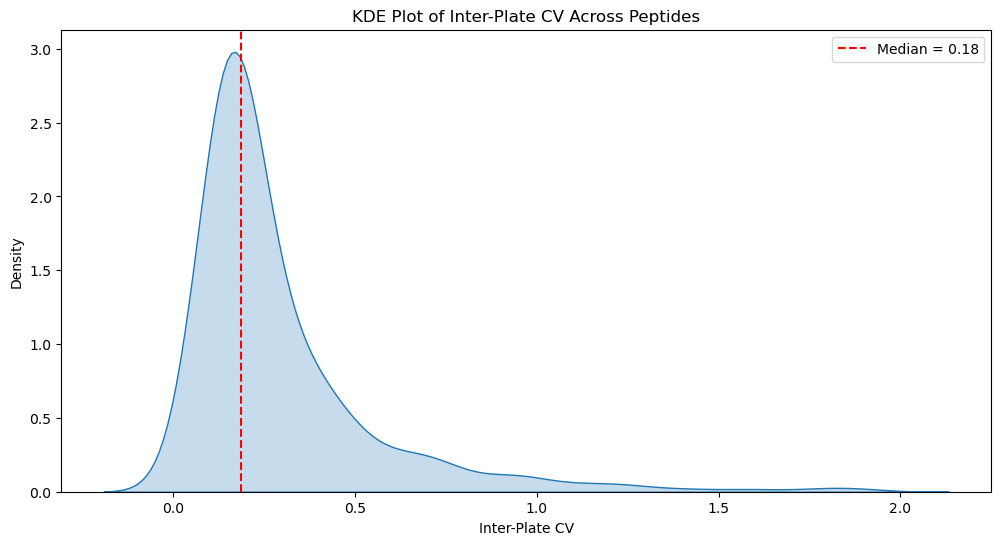

In [25]:
# Example usage:
plot_inter_plate_cv_kde(peptide_plate_stats)

In [26]:
# Example usage:
peptide_means = get_peptide_means(peptide_plate_stats)
peptide_means.head()

,Peptide Sequence,grand_mean,between_plate_sd,inter_plate_cv
0,LFINVAPHAR,0.038070,0.002431,0.063859
1,SQCTYSNPEGTVVLACDQAQCR,0.912767,0.064558,0.070728
2,VAQVIIPSTYVPGTTNHDIALLR,0.426258,0.030775,0.072199
3,LLDSLPSDTR,1.734461,0.132915,0.076632
4,FSIEGSYQLEK,0.073040,0.006625,0.090706


Total number of peptides: 309
Number of peptides with inter-plate CV < 10%: 6
Number of peptides with inter-plate CV < 20%: 172


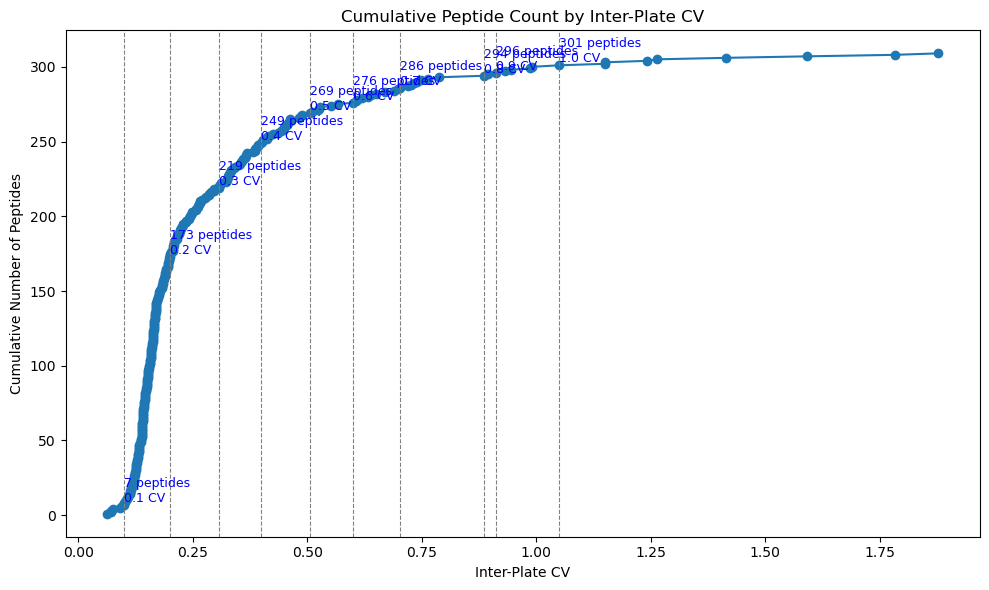

In [27]:
plot_cumulative_peptide_count_by_cv(peptide_means)

In [28]:
# Batch/Plate adjustment, correcting for each peptide within each plate (batch) 
# using only peptides in the top 10% lowest inter-plate CV for normalization

# Find the threshold for the top 10% lowest inter-plate CV peptides
cv_threshold = peptide_means['inter_plate_cv'].quantile(0.1)
# Get list of peptides in the top 10% lowest inter-plate CV
top10cv_peptides = peptide_means[peptide_means['inter_plate_cv'] <= cv_threshold]['Peptide Sequence'].unique()

# Filter pool_data to include only those peptides for normalization calculation
selected_norm_peptides = pool_data[pool_data['Peptide Sequence'].isin(top10cv_peptides)]
selected_norm_peptides

,Replicate,Peptide Sequence,Protein Name,RatioLightToHeavy,source name,characteristics[Sample],characteristics[Plate]
23281,PRM_20251128_MarthaReselection_Plate_1_G12,IASFSQNCDIYPGKDFVQPPTK,QR0350145_KNG1|P01042,1.5691,PRM_20251128_MarthaReselection_Plate_1_G12,Pool,1
23266,PRM_20251128_MarthaReselection_Plate_1_G12,GYTLADNGK,QR3730418_F10|P00742,0.6293,PRM_20251128_MarthaReselection_Plate_1_G12,Pool,1
23288,PRM_20251128_MarthaReselection_Plate_1_G12,IKVLNQELR,QR2760373_APOD|P05090,1.2309,PRM_20251128_MarthaReselection_Plate_1_G12,Pool,1
23221,PRM_20251128_MarthaReselection_Plate_1_G12,ELLLDLAKR,QR2460059_INHBC|P55103,0.0455,PRM_20251128_MarthaReselection_Plate_1_G12,Pool,1
23220,PRM_20251128_MarthaReselection_Plate_1_G12,ELLLDLAK,QR2460059_INHBC|P55103,0.0552,PRM_20251128_MarthaReselection_Plate_1_G12,Pool,1
...,...,...,...,...,...,...,...
256107,PRM_20251218_MarthaReselection_Plate_9_F12,VAAGAFQGLR,QR0350017_LRG1|P02750,1.3895,PRM_20251218_MarthaReselection_Plate_9_F12,Pool,9
256108,PRM_20251218_MarthaReselection_Plate_9_F12,VAQVIIPSTYVPGTTNHDIALLR,QR4160204_F7|P08709,0.3662,PRM_20251218_MarthaReselection_Plate_9_F12,Pool,9
259584,PRM_20251218_MarthaReselection_Plate_9_G12,CPNPPVQENFDVNK,QR2760373_APOD|P05090,0.9672,PRM_20251218_MarthaReselection_Plate_9_G12,Pool,9
259591,PRM_20251218_MarthaReselection_Plate_9_G12,DPNGLPPEAQK,QR7000009_RBP4|P02753,1.1057,PRM_20251218_MarthaReselection_Plate_9_G12,Pool,9


In [29]:
# Example usage:
model, anova_res = plate_peptide_anova(selected_norm_peptides)

                            OLS Regression Results                            
Dep. Variable:      RatioLightToHeavy   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     714.3
Date:                Sun, 05 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:09:23   Log-Likelihood:                 486.31
No. Observations:                1333   AIC:                            -894.6
Df Residuals:                    1294   BIC:                            -692.0
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

                            OLS Regression Results                            
Dep. Variable:              log_ratio   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.6053
Date:                Sun, 05 Apr 2026   Prob (F-statistic):              0.774
Time:                        23:09:23   Log-Likelihood:                -2375.4
No. Observations:                1333   AIC:                             4769.
Df Residuals:                    1324   BIC:                             4815.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.8238      0.116     -7.109

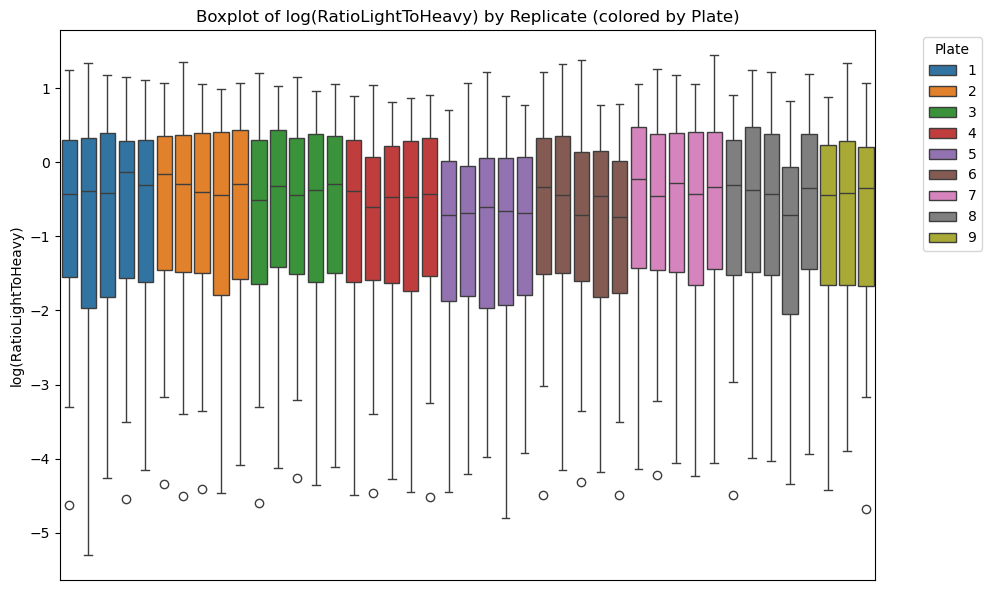

In [30]:
def fit_plate_logratio_model(selected_norm_peptides):
    """
    Fits a linear model log(RatioLightToHeavy) ~ Plate (Plate as categorical).
    Returns the fitted model and the cleaned DataFrame (with Plate and log_ratio columns).

    Args:
        selected_norm_peptides (pd.DataFrame): DataFrame containing at least 'characteristics[Plate]', 'Replicate', and 'RatioLightToHeavy'
    
    Returns:
        model: statsmodels OLS fitted model
        df: DataFrame with columns ['Plate', 'Replicate', 'RatioLightToHeavy', 'log_ratio', ...]
    """
    # Ensure required columns exist
    required_cols = ['characteristics[Plate]', 'RatioLightToHeavy', 'Replicate']
    for col in required_cols:
        if col not in selected_norm_peptides.columns:
            raise ValueError(f"Missing required column: '{col}'")

    df = selected_norm_peptides.rename(
        columns={'characteristics[Plate]': 'Plate'}
    ).copy()

    # Ensure numeric RatioLightToHeavy
    df['RatioLightToHeavy'] = pd.to_numeric(df['RatioLightToHeavy'], errors='coerce')
    df = df.dropna(subset=['RatioLightToHeavy', 'Plate'])

    # Create log_ratio column
    df['log_ratio'] = np.log(df['RatioLightToHeavy'])

    # Model: log(ratio) ~ Plate (as categorical)
    m = smf.ols('log_ratio ~ C(Plate)', data=df).fit()
    print(m.summary())

    return m, df


def plot_logratio_by_plate_boxplot(df):
    """
    Plots boxplots of log(RatioLightToHeavy) by Replicate, colored by Plate.

    Args:
        df (pd.DataFrame): DataFrame with columns ['Replicate', 'log_ratio', 'Plate']
    """
    # Sort dataframe by Plate for plotting (optional)
    df_sorted = df.sort_values('Plate')
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Replicate', y='log_ratio', data=df_sorted, hue='Plate', dodge=False)
    plt.title('Boxplot of log(RatioLightToHeavy) by Replicate (colored by Plate)')
    plt.xlabel('')
    plt.ylabel('log(RatioLightToHeavy)')
    plt.xticks([], [])  # Remove x tick labels and marks
    plt.legend(title='Plate', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Example usage:
model, df = fit_plate_logratio_model(selected_norm_peptides)
plot_logratio_by_plate_boxplot(df)

In [31]:
# Example usage:
conv_factors_df, conversion_factors, m = get_plate_conversion_factors(df)

Conversion factors for each plate (to equalize them):
  Plate  conversion_factor
0     1           1.000000
1     2           1.051056
2     3           1.058640
3     4           0.936635
4     5           0.811216
5     6           0.931216
6     7           1.097290
7     8           1.004880
8     9           0.985341


In [32]:
def adjust_ratio_by_plate(df, conversion_factors):
    """
    Normalize RatioLightToHeavy by dividing by the plate-specific conversion factor.

    Args:
        df (pd.DataFrame): DataFrame with columns 'RatioLightToHeavy' and 'Plate'.
        conversion_factors (dict): Dict mapping plate (as str or int) to factor.

    Returns:
        pd.DataFrame: Input DataFrame with added 'RatioLightToHeavy_adj' column.
    """
    def get_factor(plate):
        plate_str = str(int(plate)) if str(int(plate)) in conversion_factors else str(plate)
        return conversion_factors[plate_str]

    df = df.copy()
    df['RatioLightToHeavy_adj'] = [
        r / get_factor(p) for r, p in zip(df['RatioLightToHeavy'], df['Plate'])
    ]
    return df

# Example usage:
adjusted_df = adjust_ratio_by_plate(df, conversion_factors)
adjusted_df


,Replicate,Peptide Sequence,Protein Name,RatioLightToHeavy,source name,characteristics[Sample],Plate,log_ratio,RatioLightToHeavy_adj
23281,PRM_20251128_MarthaReselection_Plate_1_G12,IASFSQNCDIYPGKDFVQPPTK,QR0350145_KNG1|P01042,1.5691,PRM_20251128_MarthaReselection_Plate_1_G12,Pool,1,0.450502,1.569100
23266,PRM_20251128_MarthaReselection_Plate_1_G12,GYTLADNGK,QR3730418_F10|P00742,0.6293,PRM_20251128_MarthaReselection_Plate_1_G12,Pool,1,-0.463147,0.629300
23288,PRM_20251128_MarthaReselection_Plate_1_G12,IKVLNQELR,QR2760373_APOD|P05090,1.2309,PRM_20251128_MarthaReselection_Plate_1_G12,Pool,1,0.207746,1.230900
23221,PRM_20251128_MarthaReselection_Plate_1_G12,ELLLDLAKR,QR2460059_INHBC|P55103,0.0455,PRM_20251128_MarthaReselection_Plate_1_G12,Pool,1,-3.090043,0.045500
23220,PRM_20251128_MarthaReselection_Plate_1_G12,ELLLDLAK,QR2460059_INHBC|P55103,0.0552,PRM_20251128_MarthaReselection_Plate_1_G12,Pool,1,-2.896792,0.055200
...,...,...,...,...,...,...,...,...,...
256107,PRM_20251218_MarthaReselection_Plate_9_F12,VAAGAFQGLR,QR0350017_LRG1|P02750,1.3895,PRM_20251218_MarthaReselection_Plate_9_F12,Pool,9,0.328944,1.410172
256108,PRM_20251218_MarthaReselection_Plate_9_F12,VAQVIIPSTYVPGTTNHDIALLR,QR4160204_F7|P08709,0.3662,PRM_20251218_MarthaReselection_Plate_9_F12,Pool,9,-1.004576,0.371648
259584,PRM_20251218_MarthaReselection_Plate_9_G12,CPNPPVQENFDVNK,QR2760373_APOD|P05090,0.9672,PRM_20251218_MarthaReselection_Plate_9_G12,Pool,9,-0.033350,0.981589
259591,PRM_20251218_MarthaReselection_Plate_9_G12,DPNGLPPEAQK,QR7000009_RBP4|P02753,1.1057,PRM_20251218_MarthaReselection_Plate_9_G12,Pool,9,0.100479,1.122150


In [33]:
# Use the adjust_ratio_by_plate function above to add RatioLightToHeavy_adj to skyline_merge
# First, construct a Plate column of the correct type for the function
skyline_merge_adj = skyline_merge.copy()
# Make sure 'Plate' column exists and matches conversion_factors keys
skyline_merge_adj['Plate'] = skyline_merge_adj['characteristics[Plate]']
skyline_merge_adj = adjust_ratio_by_plate(skyline_merge_adj, conversion_factors)


In [34]:
# From skyline_merge_adj, filter to pool samples
pool_data_adj = skyline_merge_adj[skyline_merge_adj['characteristics[Sample]'] == 'Pool'].copy()

# If your peptide column is 'Peptide Sequence', rename it once for convenience
if 'Peptide Sequence' in pool_data_adj.columns and 'Peptide' not in pool_data_adj.columns:
    pool_data_adj = pool_data_adj.rename(columns={'Peptide Sequence': 'Peptide'})

# Filter to only peptides in selected_peptides
pool_data_adj = pool_data_adj[pool_data_adj['Peptide'].isin(selected_peptides)].copy() 



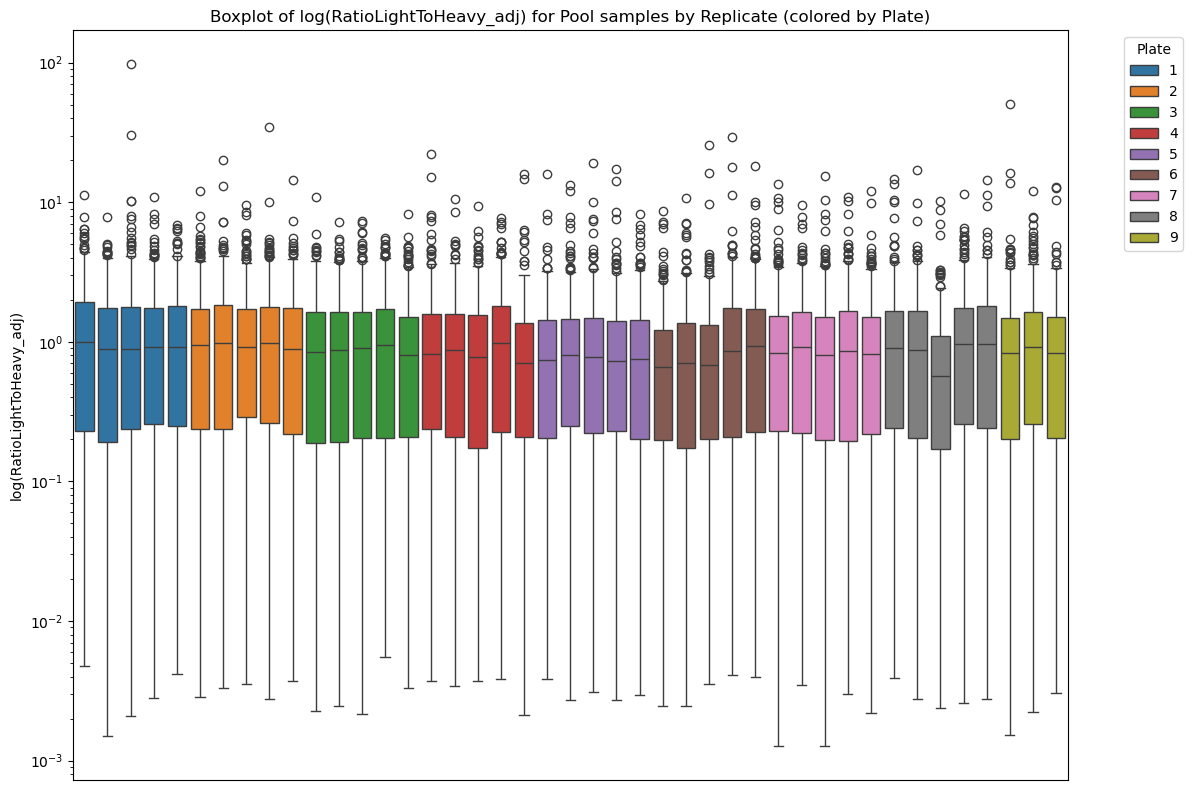

In [36]:

# Plot boxplot of log-transformed RatioLightToHeavy_adj for each Replicate, colored by Plate,
# with hidden x-axis labels and in the style of the previous plot format
df_sorted_adj = pool_data_adj.sort_values('characteristics[Plate]')
plt.figure(figsize=(12, 8))
sns.boxplot(
    x='Replicate',
    y='RatioLightToHeavy_adj',
    data=df_sorted_adj,
    hue='characteristics[Plate]'
)
plt.title('Boxplot of log(RatioLightToHeavy_adj) for Pool samples by Replicate (colored by Plate)')
plt.xlabel('')
plt.ylabel('log(RatioLightToHeavy_adj)')
plt.yscale('log')
plt.xticks([], [])  # Remove x tick labels and marks
plt.legend(title='Plate', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Calculate absolute quantification

In [37]:

# Add new column call qRePS which is the string before _ in Protein Name col
skyline_merge_adj['qRePS'] = skyline_merge_adj['Protein Name'].str.split('_').str[0]

In [38]:
# Merge qREPs_spike_levels, to skyline_merge_adj by qRePs
skyline_merge_adj = pd.merge(skyline_merge_adj, qREPs_spike_levels, on=['qRePS'], how='left')
# Add new column call qRePs which is the string before _ in Protein Name col

# Add new column called Protein conc [pmol] which is equal to RatioLightToHeavy_adj * Amount Per well [pmol]
skyline_merge_adj['Protein conc [pmol]'] = skyline_merge_adj['RatioLightToHeavy_adj'] * skyline_merge_adj['Amount per well [pmol]']

# Round Protein conc [pmol] to 4 decimal places
skyline_merge_adj['Protein conc [pmol]'] = skyline_merge_adj['Protein conc [pmol]'].round(4)


In [39]:
# Export wide format for qREPs


# Select columns to export
export_cols = ['Replicate', 'Peptide Sequence', 'Protein Name', 'qRePS', 'Protein conc [pmol]']

# Pivot the dataframe to wide format
skyline_merge_adj_wide = skyline_merge_adj.pivot(
    index=['qRePS', 'Peptide Sequence', 'Protein Name'],
    columns='Replicate',
    values='Protein conc [pmol]'
)

# Export to csv status
# skyline_merge_adj_wide.to_csv('export/MARTHA_conc_normalized.csv', index=True)


